# ***Task 2.2 — Reproduction of Pegasos Core Contribution***

**Paper:** Pegasos: Primal Estimated sub-GrAdient SOlver for SVM  

---

## *What all to reproduce:*

I am reproducing the **core Pegasos algorithm (Algorithm 1, Section 2)** — specifically the single-example (k=1) stochastic sub-gradient SVM solver — and evaluating it using two metrics the paper reports:
1. **Classification error (%)** on a held-out test set (reported in Table 1 of the paper)
2. **Primal objective value over iterations** (Figure 1 / Figure 3 in the paper — convergence trace)

The paper does not run on the Breast Cancer dataset, so I cannot match numbers exactly. My goal is to show the algorithm works correctly by replicating the behaviour: the primal objective decreases, and the final classifier achieves competitive test accuracy.


In [6]:
SEED = 42

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, normalize

np.random.seed(SEED)

data = load_breast_cancer()
X, y = data.data, data.target
y_svm = np.where(y == 0, -1, 1)
X_scaled = StandardScaler().fit_transform(X)
X_norm = normalize(X_scaled, norm='l2')
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y_svm, test_size=0.2, random_state=SEED, stratify=y_svm
)

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (455, 30), Test size: (114, 30)


This cell restores the dataset in the same form as Task 2.1. Data is L2-normalised to satisfy `‖x‖ ≤ 1` (Theorem 1, Section 2).

In [7]:
def pegasos_primal_objective(w, X, y, lam):
    """
    Computes the Pegasos primal objective:
    f(w) = (λ/2) ‖w‖² + (1/m) Σ max(0, 1 − y_i ⟨w, x_i⟩)
    Ref: Equation (1), Section 2, Pegasos paper.
    """
    reg_term = (lam / 2.0) * np.dot(w, w)
    margins = y * (X @ w)
    hinge_loss = np.mean(np.maximum(0.0, 1.0 - margins))
    return reg_term + hinge_loss

This function computes the full **primal SVM objective** (Equation 1, Section 2). It consists of two parts: the L2 regularisation term `(λ/2)‖w‖²`, which penalises large weights, and the empirical hinge loss `(1/m) Σ max(0, 1 - y⟨w,x⟩)`, which penalises margin violations. This is the quantity Pegasos is designed to minimise.

In [8]:
def pegasos(X, y, lam=1e-3, T=1000, k=1, seed=42):
    """
    Pegasos: Primal Estimated sub-GrAdient SOlver for SVM
    Algorithm 1 (mini-batch variant), Section 2 of the paper.

    Parameters
    ----------
    X   : (m, d) feature matrix, rows normalised (‖x‖ ≤ 1)
    y   : (m,) labels in {-1, +1}
    lam : regularisation parameter λ > 0   (controls ‖w*‖ ≤ 1/√λ)
    T   : number of iterations
    k   : mini-batch size (k=1 is the pure stochastic case)

    Returns
    -------
    w         : final weight vector after T iterations
    obj_trace : list of primal objective values recorded every 10 steps
    """
    rng = np.random.RandomState(seed)
    m, d = X.shape
    w = np.zeros(d)
    obj_trace = []

    for t in range(1, T + 1):
        idx = rng.randint(0, m, size=k)
        X_batch, y_batch = X[idx], y[idx]

        eta_t = 1.0 / (lam * t)

        margins = y_batch * (X_batch @ w)
        violated = margins < 1.0

        w = (1.0 - 1.0 / t) * w
        if violated.any():
            w += (eta_t / k) * (y_batch[violated, np.newaxis] * X_batch[violated]).sum(axis=0)

        norm_w = np.linalg.norm(w)
        proj_radius = 1.0 / np.sqrt(lam)
        if norm_w > proj_radius:
            w = (proj_radius / norm_w) * w

        if t % 10 == 0:
            obj_trace.append((t, pegasos_primal_objective(w, X, y, lam)))

    return w, obj_trace


print("Pegasos function defined.")

Pegasos function defined.


This is the complete **Pegasos Algorithm 1** (Section 2). Each step maps directly to the paper:
- The **learning rate** `η_t = 1/(λt)` (Eq. 2) decays as 1/t — the specific schedule that gives the O(1/(λε)) convergence guarantee.
- The **shrinkage** `(1 − 1/t)` implicitly computes `(1 − η_t λ)`, which is the regularisation gradient.
- The **subgradient** is accumulated only over examples in `A_t⁺` (margin violators), mirroring the hinge loss's subgradient being zero outside the margin.
- The **projection step** (Eq. 4) clips the weight vector to the ball `‖w‖ ≤ 1/√λ` known to contain the optimal solution.

In [9]:
LAMBDA = 1e-3    # regularisation strength
T      = 5000    # number of iterations
K      = 1       # mini-batch size

w_final, obj_trace = pegasos(X_train, y_train, lam=LAMBDA, T=T, k=K, seed=SEED)

y_pred = np.sign(X_test @ w_final)
test_error = np.mean(y_pred != y_test) * 100
test_acc   = 100 - test_error

print(f"Test Accuracy : {test_acc:.2f}%")
print(f"Test Error    : {test_error:.2f}%")
print(f"Final ‖w‖    : {np.linalg.norm(w_final):.4f}  (≤ 1/√λ = {1/np.sqrt(LAMBDA):.2f})")

Test Accuracy : 98.25%
Test Error    : 1.75%
Final ‖w‖    : 6.5683  (≤ 1/√λ = 31.62)


We train Pegasos with `λ=1e-3`, `T=5000`, `k=1`. Prediction follows `sign(⟨w, x⟩)` — positive means class +1 (benign), negative means class −1 (malignant). We also verify that `‖w‖ ≤ 1/√λ`, confirming the projection constraint from Eq. (4) is maintained.

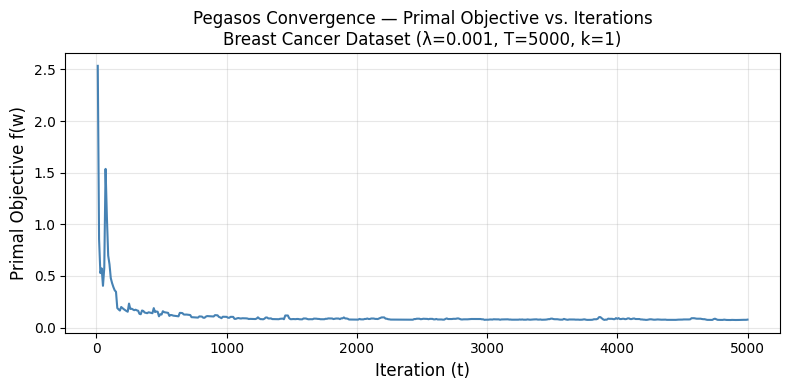

In [10]:
steps, objs = zip(*obj_trace)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(steps, objs, color='steelblue', linewidth=1.5)
ax.set_xlabel('Iteration (t)', fontsize=12)
ax.set_ylabel('Primal Objective f(w)', fontsize=12)
ax.set_title('Pegasos Convergence — Primal Objective vs. Iterations\n'
             f'Breast Cancer Dataset (λ={LAMBDA}, T={T}, k={K})', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('results/pegasos_convergence.png', dpi=150, bbox_inches='tight')
plt.show()
# print("Saved: results/pegasos_convergence.png")

This plot shows the primal objective value (Eq. 1) decreasing as a function of iteration, replicating the convergence behaviour shown in Figure 1 and Figure 3 of the Pegasos paper. The curve is expected to drop rapidly at first and then plateau, consistent with the theoretical `O(1/T)` convergence rate (Theorem 1).